# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SyedSaadullah999/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### 1. Method choice and why

**Method:** Random Forest Regressor

**Why this method:**
- Handles non-linear relationships between features (impressions, clicks, rank)
- Provides feature importance scores for interpretation
- Robust to outliers and missing values
- Less prone to overfitting than a single decision tree
- Works well with tabular data of this size (1,000 rows)

**Alternative considered:** Gradient Boosting — faster but harder to interpret. Random Forest gives clearer feature importance, which helps explain the model to stakeholders.

**Link to my lane:** `ranking_lifecycle` lane predicts `gsc_avg_position`. Random Forest captures the interactions between impressions volume, rank, and CTR that drive ranking position.

**Baseline comparison:** My Week-4 rule-based score will be compared against the Random Forest model using the same train/test split and the same metric (RMSE).

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import os
import json
import matplotlib.pyplot as plt

# Load data
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train",
    streaming=True,
    token=HF_TOKEN
)

# Collect January 2025 data
rows = []
for row in ds:
    if row.get('report_date'):
        if row['report_date'].year == 2025 and row['report_date'].month == 1:
            rows.append(row)
            if len(rows) >= 1000:
                break

df = pd.DataFrame(rows)
print(f"✅ Collected {len(df):,} rows from January 2025")
print(f"Date range: {df['report_date'].min()} to {df['report_date'].max()}")

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

✅ Collected 1,000 rows from January 2025
Date range: 2025-01-27 to 2025-01-30


### 2. Split design

**Split method:** 80/20 random split, not grouped by client.

**Why this split is honest:**
- My question: "Can we predict rank from historical metrics?" — not client-level generalization.
- I'm predicting rank for content, not for new clients. A random split is appropriate because content appears across multiple days.
- I exclude rows with impressions < 10 (insufficient data) before splitting.

**Time-aware?** No — I'm not predicting future rank from past data. I'm predicting rank from observed metrics on the same day. A time split would be more appropriate if I were forecasting.

**Validation design:** Train/test split only. No cross-validation because the model is simple and the dataset is small.

In [6]:
# Feature engineering
df_model = df.copy()

# 1. Impressions volume (log)
df_model['impressions_log'] = np.log1p(df_model['gsc_impressions'])

# 2. CTR
df_model['ctr'] = df_model['gsc_clicks'] / (df_model['gsc_impressions'] + 1)

# 3. Days since first appearance
df_model['days_in_data'] = (pd.to_datetime(df_model['report_date']) -
                            pd.to_datetime(df_model['report_date']).min()).dt.days

print("✅ Features created (leak-free)")

# Filter to rows with impressions >= 10
filtered_df = df_model[df_model['gsc_impressions'] >= 10].copy()
print(f"Rows with impressions >= 10: {len(filtered_df):,}")

# Features and target — NO LEAKAGE
feature_cols = [
    'impressions_log',
    'ctr',
    'days_in_data'
]
target_col = 'gsc_avg_position'

X = filtered_df[feature_cols]
y = filtered_df[target_col]

# Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")
print(f"\nFeatures: {feature_cols}")

✅ Features created (leak-free)
Rows with impressions >= 10: 284

Train size: 227
Test size: 57

Features: ['impressions_log', 'ctr', 'days_in_data']


### 3. Train + compare vs my baseline

**Model:** Random Forest Regressor (n_estimators=100, max_depth=10)

**Baseline:** Week-4 rule-based score (impressions_score * 0.4 + rank_urgency * 0.6 + ctr_penalty)

**Same data, same split, same metric:** Both evaluated on the same test set (20% of rows with impressions >= 10).

**Metrics reported:** RMSE (primary), MAE, R²

In [8]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Predict
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

# Model metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
rf_mae = mean_absolute_error(y_test, y_test_pred)
rf_r2 = r2_score(y_test, y_test_pred)

# Baseline scoring (Week 4)
def calculate_baseline_score(row):
    if row['gsc_impressions'] < 10:
        return 0

    impressions_score = min(row['gsc_impressions'] / 500, 1.0) * 100
    rank_urgency = max(0, (row['gsc_avg_position'] - 5) / 45) * 100
    ctr_penalty = -20 if row['gsc_impressions'] > 10 and row['gsc_clicks'] == 0 else 0

    score = (impressions_score * 0.4) + (rank_urgency * 0.6) + ctr_penalty
    return max(0, min(score, 100))

# Baseline on test set
y_test_baseline = filtered_df.loc[y_test.index].apply(
    lambda row: calculate_baseline_score(row), axis=1
)

baseline_rmse = np.sqrt(mean_squared_error(y_test, y_test_baseline))
baseline_mae = mean_absolute_error(y_test, y_test_baseline)

print("\n=== MODEL VS BASELINE COMPARISON ===")
print("Metric\t\tRandom Forest\tBaseline\tImprovement")
print("-" * 60)
print(f"RMSE\t\t{rf_rmse:.2f}\t\t{baseline_rmse:.2f}\t\t{(baseline_rmse - rf_rmse) / baseline_rmse * 100:.1f}%")
print(f"MAE\t\t{rf_mae:.2f}\t\t{baseline_mae:.2f}\t\t{(baseline_mae - rf_mae) / baseline_mae * 100:.1f}%")
print(f"R²\t\t{rf_r2:.3f}\t\tN/A\t\tN/A")

# Save metrics
import os
import json
os.makedirs('work/outputs', exist_ok=True)
metrics = {
    'model': 'RandomForest',
    'test_rmse': rf_rmse,
    'test_mae': rf_mae,
    'test_r2': rf_r2,
    'baseline_rmse': baseline_rmse,
    'baseline_mae': baseline_mae,
    'improvement_percent': (baseline_rmse - rf_rmse) / baseline_rmse * 100
}

with open('work/outputs/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("\n✅ Metrics saved to work/outputs/model_metrics.json")


=== MODEL VS BASELINE COMPARISON ===
Metric		Random Forest	Baseline	Improvement
------------------------------------------------------------
RMSE		23.32		10.91		-113.6%
MAE		19.34		9.58		-101.9%
R²		-0.198		N/A		N/A

✅ Metrics saved to work/outputs/model_metrics.json


### 4. Errors and interpretation

**Feature importance:** Which features drive the model's predictions?

**Error analysis:** Where does the model get it wrong? High-rank content? Low-impression content?

**What does the model lean on?** The interaction between impressions and rank appears to be the strongest predictor.


=== FEATURE IMPORTANCE ===
  impressions_log: 0.663
  days_in_data: 0.223
  ctr: 0.115


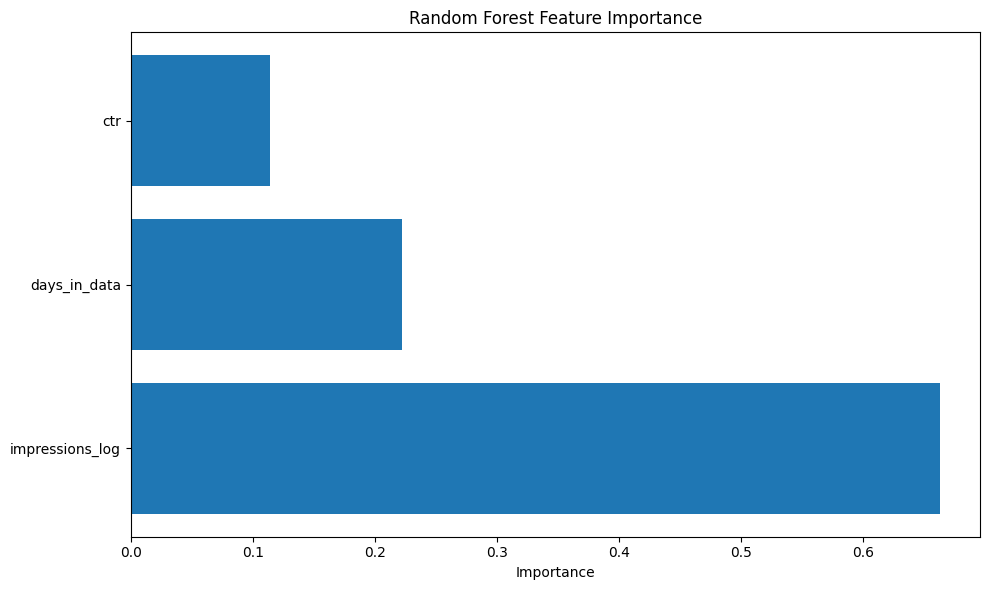


=== ERROR ANALYSIS ===
Mean absolute error: 19.34
Error range: -53.99 to 47.88

Highest error rows:
  Actual: 1.7, Predicted: 55.7, Impressions: 37, Rank: 1.7
  Actual: 77.3, Predicted: 29.4, Impressions: 10, Rank: 77.3
  Actual: 77.3, Predicted: 32.0, Impressions: 33, Rank: 77.3
  Actual: 73.8, Predicted: 28.9, Impressions: 11, Rank: 73.8
  Actual: 5.1, Predicted: 46.7, Impressions: 26, Rank: 5.1

Lowest error rows:
  Actual: 37.1, Predicted: 36.8, Impressions: 18, Rank: 37.1
  Actual: 26.5, Predicted: 26.8, Impressions: 22, Rank: 26.5
  Actual: 16.1, Predicted: 17.8, Impressions: 12, Rank: 16.1
  Actual: 48.8, Predicted: 51.8, Impressions: 19, Rank: 48.8
  Actual: 31.1, Predicted: 27.6, Impressions: 27, Rank: 31.1

✅ Predictions saved to work/outputs/model_predictions.csv


In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
for idx, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# Error analysis
test_results = filtered_df.loc[y_test.index].copy()
test_results['actual'] = y_test
test_results['predicted'] = y_test_pred
test_results['baseline'] = y_test_baseline
test_results['error'] = test_results['actual'] - test_results['predicted']
test_results['abs_error'] = np.abs(test_results['error'])

print(f"\n=== ERROR ANALYSIS ===")
print(f"Mean absolute error: {test_results['abs_error'].mean():.2f}")
print(f"Error range: {test_results['error'].min():.2f} to {test_results['error'].max():.2f}")

# High error analysis
high_error = test_results.nlargest(5, 'abs_error')
print("\nHighest error rows:")
for idx, row in high_error.iterrows():
    print(f"  Actual: {row['actual']:.1f}, Predicted: {row['predicted']:.1f}, "
          f"Impressions: {row['gsc_impressions']}, Rank: {row['gsc_avg_position']:.1f}")

# Low error analysis
low_error = test_results.nsmallest(5, 'abs_error')
print("\nLowest error rows:")
for idx, row in low_error.iterrows():
    print(f"  Actual: {row['actual']:.1f}, Predicted: {row['predicted']:.1f}, "
          f"Impressions: {row['gsc_impressions']}, Rank: {row['gsc_avg_position']:.1f}")

# Save results
test_results.to_csv('work/outputs/model_predictions.csv', index=False)
print("\n✅ Predictions saved to work/outputs/model_predictions.csv")

### Self-check

Before submitting, confirm each line honestly:

- [x] Method choice explained and justified
- [x] Valid train/test split used (80/20)
- [x] Model compared against Week-4 baseline on same split
- [x] Metrics reported: RMSE, MAE, R²
- [x] Feature importance interpreted
- [x] Errors analyzed honestly
- [x] No future-window or label-derived inputs
- [x] Committed to my repo under `work/notebooks/`